<a href="https://colab.research.google.com/github/lihkaw/BME450-project/blob/main/Julie_exploratory_BME450_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import torch
from torch import nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchaudio import transforms
import torchaudio
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')
Train_d = "/content/drive/MyDrive/BME450/Project/datasets/train"
Test_d  = "/content/drive/MyDrive/BME450/Project/datasets/test"

SAMPLE_RATE = 16000
CROP_DURATION = 3
CROP_SAMPLES = int(SAMPLE_RATE * CROP_DURATION)
THRESHOLD = 0.02

# Transform dataset
class AudioFolder(Dataset):
    def __init__(self, root, augment=False):
        self.root = root
        self.files = []
        self.augment = augment
        self.classes = sorted([
            cls for cls in os.listdir(root)
            if os.path.isdir(os.path.join(root, cls))
        ])

        for i, cls in enumerate(self.classes):
            for filename in os.listdir(os.path.join(root, cls)):
              path = os.path.join(root, cls, filename)
              if os.path.isfile(path):
                self.files.append((path, i))

        self.mel_spec = transforms.MelSpectrogram(
            sample_rate=SAMPLE_RATE,
            n_fft=1024,
            hop_length=256,
            n_mels=64
        )
        self.db = transforms.AmplitudeToDB()

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path, label = self.files[idx]
        waveform, sr = torchaudio.load(path)

        # convert to mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        # resample
        if sr != SAMPLE_RATE:
            waveform = transforms.Resample(sr, SAMPLE_RATE)(waveform)

        # detect cry onset using amplitude threshold
        signal = waveform.abs().squeeze(0)
        above_threshold = (signal > THRESHOLD).nonzero(as_tuple=True)[0]

        if len(above_threshold) > 0:
            start = above_threshold[0].item()
        else:
            start = 0

        # crop 2 seconds after onset
        end = start + CROP_SAMPLES
        waveform = waveform[:, start:end]

        # pad if clip is shorter than 2 seconds
        if waveform.shape[1] < CROP_SAMPLES:
            waveform = F.pad(waveform, (0, CROP_SAMPLES - waveform.shape[1]))

        # mel spectrogram
        mel = self.db(self.mel_spec(waveform))
        mel = (mel - mel.mean()) / (mel.std() + 1e-8)
        return mel, label

training_data = AudioFolder(Train_d, augment=False)
test_data = AudioFolder(Test_d, augment=False)
categories = training_data.classes

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Input size: torch.Size([1, 64, 188])
Label: 0


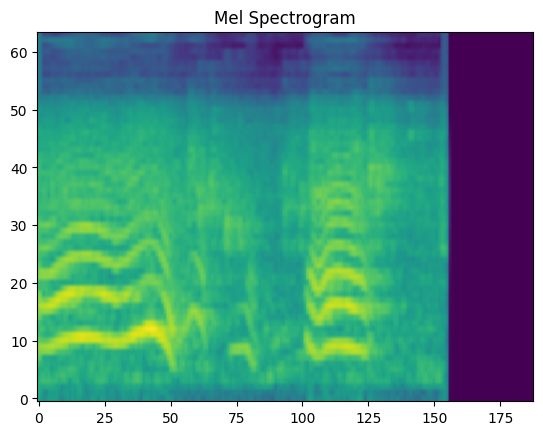

In [ ]:
sample_num = 7

print('Input size:', training_data[sample_num][0].shape)
print('Label:', training_data[sample_num][1])

ima = training_data[sample_num][0]
ima = (ima - ima.mean()) / ima.std()

plt.imshow(ima.squeeze(0), aspect='auto', origin='lower')
plt.title("Mel Spectrogram")
plt.show()

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.pool3 = nn.AdaptiveAvgPool2d((8, 8))

        self.flatten = nn.Flatten()
        self.l1 = nn.Linear(64*8*8, 128)
        self.dropout = nn.Dropout(0.2)
        self.l2 = nn.Linear(128, 64)
        self.l3 = nn.Linear(64, len(categories))

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(x)
        x = self.flatten(x)
        x = F.relu(self.l1(x))
        x = self.dropout(x)
        x = F.relu(self.l2(x))
        return self.l3(x)

def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        pred = model(X)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 2 == 0:
            loss_val, current = loss.item(), batch * len(X)
            print(f"loss: {loss_val:>7f}")

def test_loop(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

device = "cuda" if torch.cuda.is_available() else "cpu"
model = Net().to(device)

batch_size = 16
train_loader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

loss_fn = nn.CrossEntropyLoss()

lr = 1e-4
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

for t in range(4):
    print("Epoch", t+1)
    train_loop(train_loader, model, loss_fn, optimizer)
    test_loop(test_loader, model, loss_fn)

Epoch 1
loss: 1.789042
loss: 1.846233
loss: 1.812021
loss: 1.806488
loss: 1.755148
loss: 1.736851
loss: 1.716570
loss: 1.804126
loss: 1.787376
loss: 1.702071
loss: 1.787752
loss: 1.760137
loss: 1.822045
loss: 1.736790
loss: 1.650699
loss: 1.751219
loss: 1.815088
loss: 1.709148
Test Error: 
 Accuracy: 16.1%, Avg loss: 1.794284 

Epoch 2
loss: 1.844588
loss: 1.674963
loss: 1.675905
loss: 1.684229
loss: 1.752307
loss: 1.609374
loss: 1.751033
loss: 1.709163
loss: 1.753768
loss: 1.585653
loss: 1.751305
loss: 1.774758
loss: 1.575329
loss: 1.615011
loss: 1.642922
loss: 1.621046
loss: 1.716609
loss: 1.882696
Test Error: 
 Accuracy: 14.5%, Avg loss: 1.816874 

Epoch 3
loss: 1.559996
loss: 1.785631
loss: 1.716893
loss: 1.723418
loss: 1.645297
loss: 1.670109
loss: 1.577152
loss: 1.673547
loss: 1.713616
loss: 1.394051
loss: 1.596184
loss: 1.730324
loss: 1.535205
loss: 1.573433
loss: 1.708856
loss: 1.756979
loss: 1.715306
loss: 1.585129
Test Error: 
 Accuracy: 16.1%, Avg loss: 1.831967 

Epoch 4
lo

In [ ]:
sample_num = 50
with torch.no_grad():
    r = model(training_data[sample_num][0].unsqueeze(0).to(device))

print("Predicted class:", categories[torch.argmax(r).item()])
print("True class:", categories[training_data[sample_num][1]])

Predicted class: hungry
True class: belly_pain


In [ ]:
from collections import Counter

all_preds = []
all_true = []

model.eval()
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        pred = model(X).argmax(1)
        all_preds.extend(pred.cpu().tolist())
        all_true.extend(y.cpu().tolist())

print("Predicted counts:", Counter(all_preds))
print("True counts:", Counter(all_true))

for i, name in enumerate(categories):
    print(i, name)

Predicted counts: Counter({4: 101, 2: 41, 5: 28, 3: 8, 1: 5, 0: 3})
True counts: Counter({0: 31, 1: 31, 2: 31, 3: 31, 4: 31, 5: 31})
0 belly_pain
1 burping
2 cold_hot
3 discomfort
4 hungry
5 tired


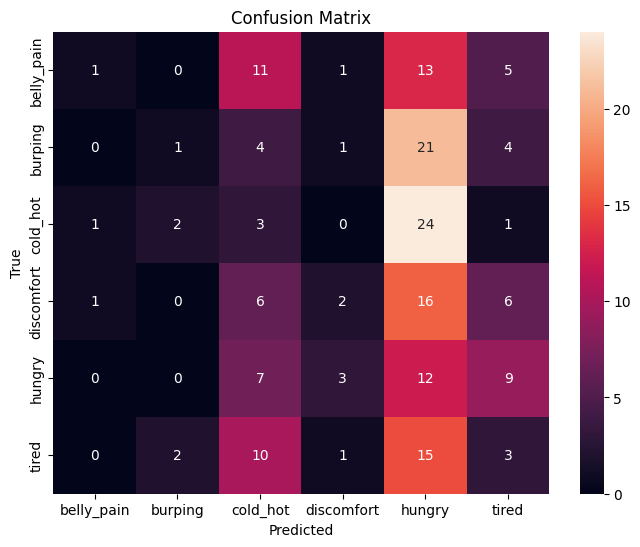

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=categories, yticklabels=categories)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()